# Bearing Health-State Classification and RUL Prediction

This notebook trains a Random Forest model to predict the Remaining Useful Life (RUL) of bearings using extracted vibration features.

Import Libraries
- Required Python libraries for data handling, model training, evaluation, saving the model, and visualization. 

In [56]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Load Training Feature Data
- The file `train_features.csv` contains the extracted vibration features and the target RUL values.

In [57]:
DATA_PATH = Path("train_features.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape:
(7534, 16)

Columns:
['rms_x', 'peak_x', 'kurtosis_x', 'skew_x', 'std_x', 'crest_x', 'rms_y', 'peak_y', 'kurtosis_y', 'skew_y', 'std_y', 'crest_y', 'time_step', 'total_steps', 'RUL', 'bearing']


,rms_x,peak_x,kurtosis_x,skew_x,std_x,crest_x,rms_y,peak_y,kurtosis_y,skew_y,std_y,crest_y,time_step,total_steps,RUL,bearing
0,0.561746,2.010,-0.131465,-0.004711,0.561735,3.578132,0.435801,1.591,-0.035080,0.002713,0.435797,3.650745,0,2803,2802,Bearing1_1
1,0.535112,1.915,-0.084646,-0.025791,0.535083,3.578687,0.420968,1.666,0.150620,0.077380,0.420967,3.957542,1,2803,2801,Bearing1_1
2,0.531158,1.901,0.033388,-0.005016,0.531142,3.578971,0.425605,1.584,-0.061552,-0.024393,0.425600,3.721758,2,2803,2800,Bearing1_1
3,0.554833,1.910,0.043419,-0.080165,0.554830,3.442476,0.445524,1.600,-0.113319,-0.008190,0.445524,3.591275,3,2803,2799,Bearing1_1
4,0.566652,1.767,-0.185477,-0.034187,0.566646,3.118317,0.423847,1.373,-0.034816,0.081213,0.423731,3.239377,4,2803,2798,Bearing1_1


Inspect Dataset Columns
- This step checks all available columns to identify feature columns, target column, and bearing identifier.

In [58]:
for i, col in enumerate(df.columns):
    print(i, ":", col)

0 : rms_x
1 : peak_x
2 : kurtosis_x
3 : skew_x
4 : std_x
5 : crest_x
6 : rms_y
7 : peak_y
8 : kurtosis_y
9 : skew_y
10 : std_y
11 : crest_y
12 : time_step
13 : total_steps
14 : RUL
15 : bearing


Prepare Features and Target
- The input features are vibration statistics from x and y accelerometer signals.  
- The target variable is `RUL`, and `bearing` is used for grouped splitting.

In [59]:
feature_cols = [
    'rms_x',
    'peak_x',
    'kurtosis_x',
    'skew_x',
    'std_x',
    'crest_x',
    'rms_y',
    'peak_y',
    'kurtosis_y',
    'skew_y',
    'std_y',
    'crest_y',
    'time_step',
    'total_steps'
]

X = df[feature_cols]

y = df['RUL']

groups = df['bearing']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7534, 14)
Target shape: (7534,)


Train-Test Split by Bearing
- The dataset is split by bearing using `GroupShuffleSplit` to avoid data leakage.  
- This ensures samples from the same bearing are not present in both training and test sets.

In [60]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 3860
Test samples: 3674


Train Random Forest Regressor
- A Random Forest Regressor is trained to predict the Remaining Useful Life.  
- Random Forest is suitable because it works well with tabular features and provides feature importance.

In [61]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=2,
    n_jobs=-1
)

print("Training model...")

model.fit(X_train, y_train)

print("Training complete!")

Training model...
Training complete!


Generate RUL Predictions
- The trained model predicts RUL values for the held-out test bearings.

In [62]:
y_pred = model.predict(X_test)

print("Predictions complete!")

print(y_pred[:10])

Predictions complete!
[1608.86876984 1608.59355159 1608.75818651 1608.80463095 1608.84468651
 1608.5943254  1608.58713095 1607.94671032 1607.84686508 1607.62775   ]


Evaluate Model Performance
- The model is evaluated using RMSE, MAE, and R² score.

In [63]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 873.0335978874286
MAE: 713.179446283381
R2 Score: -0.11548114337064108


Calculate PHM Score
- The PHM score is an asymmetric metric that penalizes late predictions more strongly than early predictions.

In [64]:
def phm_score(y_true, y_pred):

    score = 0

    for true, pred in zip(y_true, y_pred):

        d = pred - true

        if d < 0:
            score += np.exp(-d / 13) - 1

        else:
            score += np.exp(d / 10) - 1

    return score


score = phm_score(y_test.values, y_pred)

print("PHM Score:", score)

PHM Score: 1.64192893911823e+43


Estimate Prediction Uncertainty
- Uncertainty is estimated using the standard deviation of predictions across all trees in the Random Forest.

In [65]:
tree_predictions = np.array([
    tree.predict(X_test)
    for tree in model.estimators_
])

prediction_mean = tree_predictions.mean(axis=0)

prediction_std = tree_predictions.std(axis=0)

print("Uncertainty estimation complete!")

print(prediction_std[:10])

c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X 

Uncertainty estimation complete!
[78.19934705 78.15115961 78.18669773 78.19971587 78.20033384 78.14793408
 78.13563964 77.98984668 77.96088828 77.89589854]


c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X 

Create Results Table

The final results table contains:

- Actual Remaining Useful Life (RUL)
- Predicted RUL
- Prediction uncertainty
- 95% confidence bounds
- Actual health-state class
- Predicted health-state class

This table summarizes the performance of the predictive maintenance model
and converts continuous RUL predictions into practical maintenance categories.

In [66]:
results = df.iloc[test_idx][["bearing", "time_step", "total_steps"]].copy()

results["Actual_RUL"] = y_test.values
results["Predicted_RUL"] = prediction_mean
results["Uncertainty"] = prediction_std
results["Lower_RUL"] = prediction_mean - 1.96 * prediction_std
results["Upper_RUL"] = prediction_mean + 1.96 * prediction_std


def rul_to_health_state(rul):
    if rul > 200:
        return "Non-critical"
    elif rul > 80:
        return "Wear detectable"
    else:
        return "Imminent failure"


results["Actual_Health_State"] = results["Actual_RUL"].apply(rul_to_health_state)
results["Predicted_Health_State"] = results["Predicted_RUL"].apply(rul_to_health_state)

results.head()

,bearing,time_step,total_steps,Actual_RUL,Predicted_RUL,Uncertainty,Lower_RUL,Upper_RUL,Actual_Health_State,Predicted_Health_State
0,Bearing1_1,0,2803,2802,1608.868770,78.199347,1455.598050,1762.139490,Non-critical,Non-critical
1,Bearing1_1,1,2803,2801,1608.593552,78.151160,1455.417279,1761.769824,Non-critical,Non-critical
2,Bearing1_1,2,2803,2800,1608.758187,78.186698,1455.512259,1762.004114,Non-critical,Non-critical
3,Bearing1_1,3,2803,2799,1608.804631,78.199716,1455.533188,1762.076074,Non-critical,Non-critical
4,Bearing1_1,4,2803,2798,1608.844687,78.200334,1455.572032,1762.117341,Non-critical,Non-critical


Save Prediction Results

The final prediction results are saved as:

- `rul_predictions_with_health_states.csv`

The saved file contains:

- Actual RUL
- Predicted RUL
- Prediction uncertainty
- Confidence intervals
- Actual health-state labels
- Predicted health-state labels

This file can be used for further visualization, reporting, and maintenance analysis.

In [67]:
results.to_csv("rul_predictions_with_health_states.csv", index=False)

print("Saved rul_predictions_with_health_states.csv")

Saved rul_predictions_with_health_states.csv


Health-State Classification Evaluation

This step evaluates how well the predicted Remaining Useful Life (RUL) values map to bearing health conditions.

The predicted and actual RUL values are converted into three health-state classes:

- Non-critical → Bearing operating normally
- Wear detectable → Early degradation detected
- Imminent failure → Bearing close to failure

The following evaluation metrics are computed:

- Classification accuracy
- Precision, recall, and F1-score
- Confusion matrix for class-wise performance analysis

This provides an interpretable maintenance-oriented assessment of the predictive maintenance system.

In [68]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

health_accuracy = accuracy_score(
    results["Actual_Health_State"],
    results["Predicted_Health_State"]
)

print("Health-State Classification Accuracy:", health_accuracy)

print("\nClassification Report:")
print(classification_report(
    results["Actual_Health_State"],
    results["Predicted_Health_State"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    results["Actual_Health_State"],
    results["Predicted_Health_State"]
))

Health-State Classification Accuracy: 0.6292868807838867

Classification Report:
                  precision    recall  f1-score   support

Imminent failure       0.10      0.78      0.17       162
    Non-critical       0.98      0.64      0.78      3272
 Wear detectable       0.36      0.35      0.35       240

        accuracy                           0.63      3674
       macro avg       0.48      0.59      0.43      3674
    weighted avg       0.90      0.63      0.72      3674


Confusion Matrix:
[[ 126    0   36]
 [1056 2102  114]
 [ 120   36   84]]


Visualization: Predicted Health-State Distribution

- This visualization shows the number of predicted samples in each bearing health-state category.
- The categories help interpret bearing condition for predictive maintenance:
  - Non-critical
  - Wear detectable
  - Imminent failure
- This plot provides an overview of the maintenance condition distribution across the dataset.

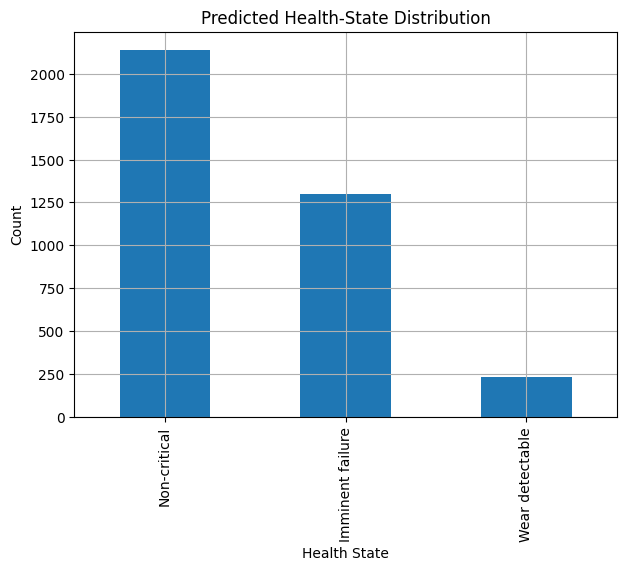

In [73]:
import matplotlib.pyplot as plt

results["Predicted_Health_State"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Predicted Health-State Distribution")
plt.xlabel("Health State")
plt.ylabel("Count")
plt.grid(True)

plt.show()

Save Trained Model
- The trained Random Forest model is saved as a `.pkl` file for future reuse.

In [69]:
import joblib

joblib.dump(model, "random_forest_rul_model.pkl")

print("Model saved!")

Model saved!


Visualization: Actual vs Predicted RUL
- This plot compares the true RUL values with the model predictions.

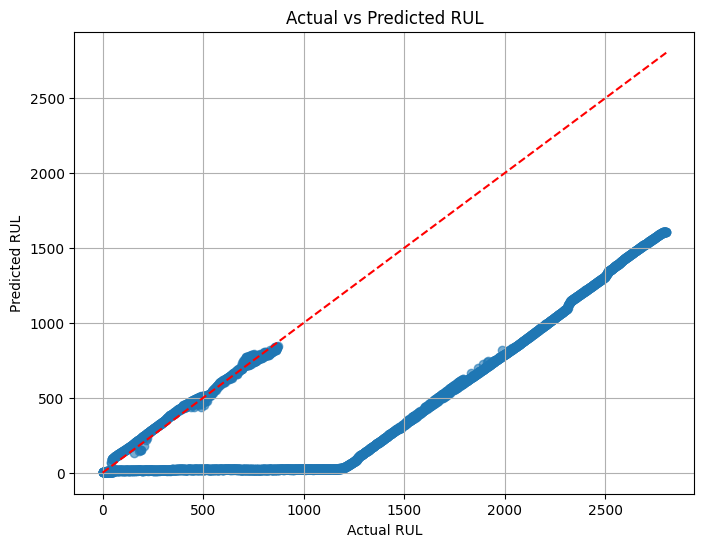

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    results["Actual_RUL"],
    results["Predicted_RUL"],
    alpha=0.6
)

min_val = min(results["Actual_RUL"].min(),
              results["Predicted_RUL"].min())

max_val = max(results["Actual_RUL"].max(),
              results["Predicted_RUL"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.grid(True)

plt.show()

Visualization: Feature Importance
- This plot shows which vibration features contributed most to the Random Forest prediction.

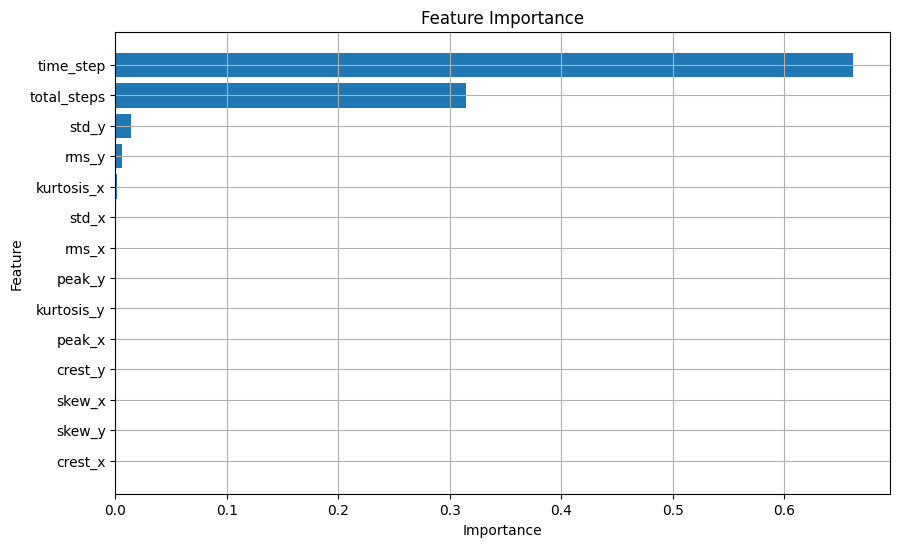

In [71]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.grid(True)

plt.show()

Final Summary Report
- This section summarizes the model, evaluation results, and output files.

In [72]:
print("="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"Number of samples: {len(df)}")
print(f"Number of features: {len(feature_cols)}")
print(f"Model: Random Forest Regressor")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.3f}")
print(f"PHM Score: {score:.2f}")
print(f"Output file: rul_predictions.csv")
print(f"Saved model: random_forest_rul_model.pkl")
print(f"Health-State Accuracy: {health_accuracy:.3f}")
print(f"Output file: rul_predictions_with_health_states.csv")
print("="*70)

FINAL SUMMARY
Number of samples: 7534
Number of features: 14
Model: Random Forest Regressor
RMSE: 873.03
MAE: 713.18
R2 Score: -0.115
PHM Score: 16419289391182299022445735912093617848582144.00
Output file: rul_predictions.csv
Saved model: random_forest_rul_model.pkl
Health-State Accuracy: 0.629
Output file: rul_predictions_with_health_states.csv


In [74]:
latest_status = results.sort_values("time_step").groupby("bearing").last().reset_index()

latest_status[[
    "bearing",
    "time_step",
    "Predicted_RUL",
    "Uncertainty",
    "Lower_RUL",
    "Upper_RUL",
    "Predicted_Health_State"
]]

,bearing,time_step,Predicted_RUL,Uncertainty,Lower_RUL,Upper_RUL,Predicted_Health_State
0,Bearing1_1,2802,2.351196,1.554496,-0.695617,5.398008,Imminent failure
1,Bearing1_2,870,2.372392,1.717873,-0.994640,5.739423,Imminent failure


In [75]:
for _, row in latest_status.iterrows():
    print(f"Bearing: {row['bearing']}")
    print(f"Predicted RUL: {row['Predicted_RUL']:.2f} steps")
    print(f"Uncertainty: ±{row['Uncertainty']:.2f} steps")
    print(f"Health State: {row['Predicted_Health_State']}")

    if row["Predicted_Health_State"] == "Imminent failure":
        print("Action: Replace soon / urgent maintenance needed.")
    elif row["Predicted_Health_State"] == "Wear detectable":
        print("Action: Monitor closely; schedule maintenance.")
    else:
        print("Action: Bearing is currently non-critical.")

    print("-" * 50)

Bearing: Bearing1_1
Predicted RUL: 2.35 steps
Uncertainty: ±1.55 steps
Health State: Imminent failure
Action: Replace soon / urgent maintenance needed.
--------------------------------------------------
Bearing: Bearing1_2
Predicted RUL: 2.37 steps
Uncertainty: ±1.72 steps
Health State: Imminent failure
Action: Replace soon / urgent maintenance needed.
--------------------------------------------------
